<img src="images/banner.png" style="width: 100%;">

In [36]:
import os
os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" # Enable in M1 Mac CPUs

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 1.5})

# Time Series Forecasting using RNNs

Based from previous ML3 notebooks prepared by Christopher Monterola, Kenneth Co. Updated by Leodegario Lorenzo II (2026)

In this notebook, we’ll demonstrate three advanced techniques for improving the performance and generalization power of recurrent neural networks.  We’ll demonstrate all three concepts on a temperature-forecasting problem, where you have access to a timeseries of data points coming from sensors installed on the roof of a building, such as temperature, air pressure, and humidity, which you use to predict what the temperature will be 24 hours after the last data point.

This is a fairly challenging problem that exemplifies many common difficulties encountered when working with timeseries. We’ll cover the following techniques:
- **Modern RNNs** - LSTMs and GRUs
- **Recurrent dropout** — This is a specific, built-in way to use dropout to fight overfitting in recurrent layers.    
- Stacking **recurrent layers** — This increases the representational power of the network (at the cost of higher computational loads).
- **bidirecational layers** - These present the same information to the neural network in different ways.   

## 1 Data Loading

In all the examples in this section, we'll work with a weather timeseries dataset recorded at the Weather Station at the Max Planck Institute for Biogeochemistry in Jena, Germany.

In this dataset, 14 different quantities (such air temperature, atmospheric pressure, humidity, wind direction, and so on) were recorded every 10 minutes, over several years. The original data goes back to 2003, but this example is limited to data from 2009–2016. This dataset is perfect for learning to work with numerical timeseries. You’ll use it to build a model that takes as input some data from the recent past (a few days’ worth of data points) and predicts the air temperature 24 hours in the future.

Here are the actual variables in the data:
* Date Time   
* p (mbar) atmospheric pressure  
* T (degC) temperature  
* Tpot (K) potential temperature  
* Tdew (degC) dew point temperature  
* rh (%) relative humidity  
* VPmax (mbar) saturation water vapor pressure  
* VPact (mbar) actual water vapor pressure  
* VPdef (mbar) water vapor pressure deficit  
* sh (g/kg) specific humidity  
* H2OC (mmol/mol) water vapor concentration  
* rho (g/$m^3$) air density  
* wv (m/s) wind velocity  
* max. wv (m/s) maximum wind velocity  
* wd (deg) wind direction  


To download the dataset, run the code cell below:

In [3]:
# !wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
# !unzip jena_climate_2009_2016.csv.zip

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [6]:
import pandas as pd

In [28]:
data = pd.read_csv('jena_climate_2009_2016.csv')
data['Date Time'] = pd.to_datetime(data['Date Time'], dayfirst=True)

In [30]:
data.dtypes

Date Time          datetime64[us]
p (mbar)                  float64
T (degC)                  float64
Tpot (K)                  float64
Tdew (degC)               float64
rh (%)                    float64
VPmax (mbar)              float64
VPact (mbar)              float64
VPdef (mbar)              float64
sh (g/kg)                 float64
H2OC (mmol/mol)           float64
rho (g/m**3)              float64
wv (m/s)                  float64
max. wv (m/s)             float64
wd (deg)                  float64
dtype: object

## 2 Data Exploration

Let's perform a quick exploration of the data by visualizing the temperature timeseries.

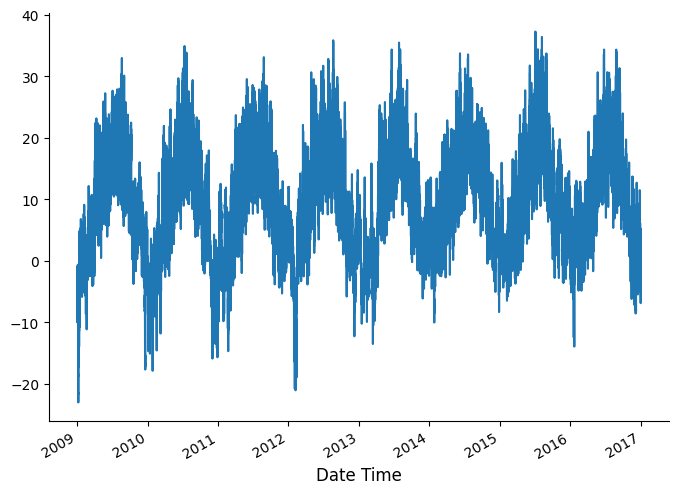

In [37]:
data.set_index('Date Time')['T (degC)'].plot();

We can clearly see the yearly periodicity of the temperature.

Below is a more narrow plot of the first 10 days of temperature data or first 1440 data points. Because the data is recorded every 10 minutes, you get 144 data points daily.

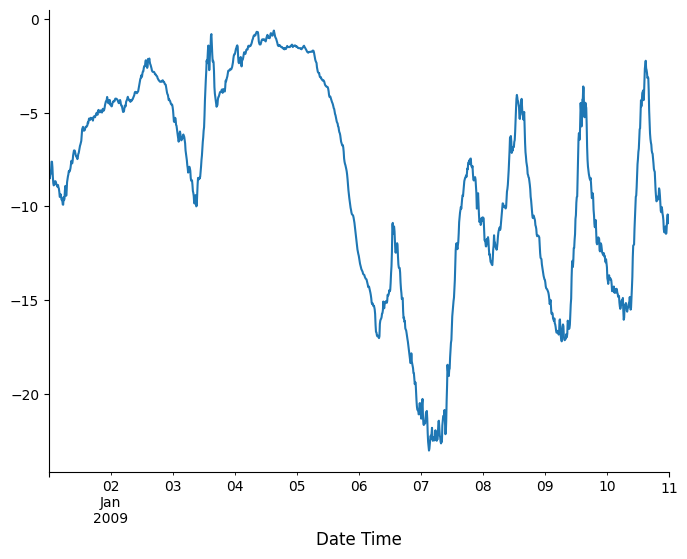

In [39]:
data.set_index('Date Time').iloc[:1440]['T (degC)'].plot();

On this plot, you can see daily periodicity, especially evident for the last 4 days. Also note that this 10-day period must be coming from a fairly cold winter month. If you were trying to predict average temperature for the next month given a few months of past data, the problem would be easy, due to the reliable year-scale periodicity
of the data.

But looking at the data over a scale of days, the temperature looks a lot more chaotic. Is this timeseries predictable at a daily scale? Let’s find out. Shown below are plots for 100 days ($2880*5$) and 200 days ($2880*10$)

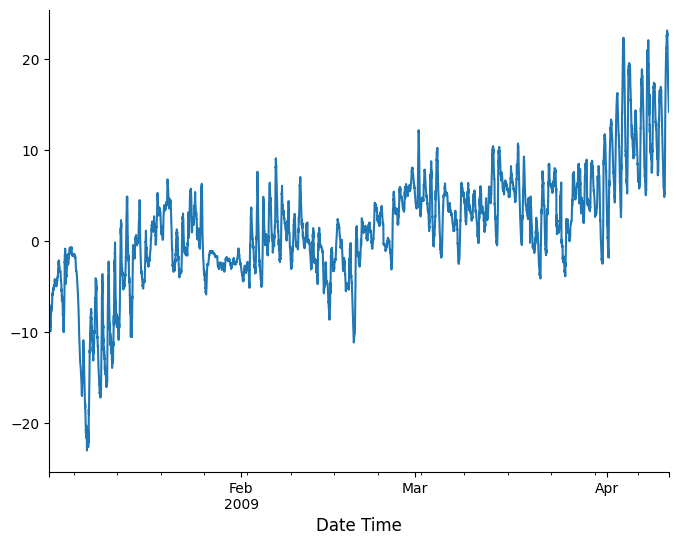

In [40]:
data.set_index('Date Time').iloc[:2880*5]['T (degC)'].plot();

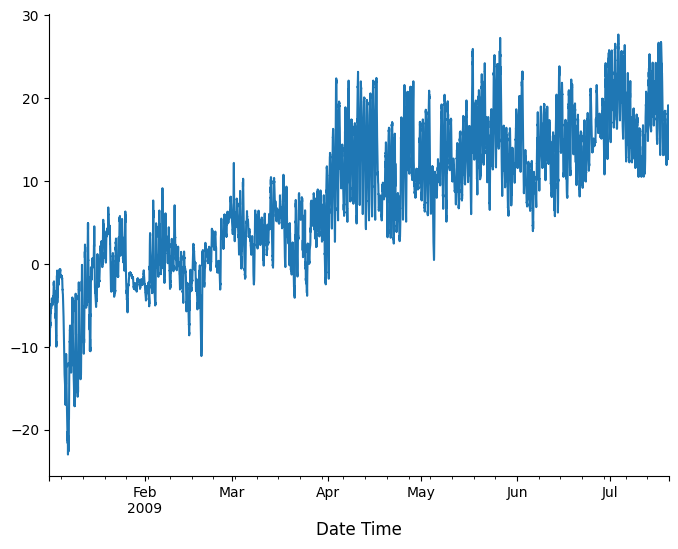

In [41]:
data.set_index('Date Time').iloc[:2880*10]['T (degC)'].plot();

## 3 Data Preparation

The predictors that we will use for this problem are the environmental variables measured by the sensors. Meanwhile, we will predict the temperature based from the historical reading of the sensors.

In [70]:
predictors = data.iloc[:, 1:].to_numpy().astype('float32')
targets = data.iloc[:, 2].to_numpy().astype('float32')

### Data Segregation

For this problem, let's use half of the total samples as our training set, then use the remaining half for both the validation and test dataset.

In [71]:
num_train_samples = int(0.5 * len(data))
num_val_samples = int(0.25 * len(data))
num_test_samples = len(data) - num_train_samples - num_val_samples
print("Number of Training Samples:", num_train_samples)
print("Number of Validation Samples:", num_val_samples)
print("Number of Test Samples:", num_test_samples)

Number of Training Samples: 210225
Number of Validation Samples: 105112
Number of Test Samples: 105114


### Data Normalization

We preprocess the data to a format a neural network can ingest. This is easy: the data is already numerical, so you don’t need to do any vectorization. But each time series in the data is on a different scale (for example, temperature is typically between -20 and +30 celsius, but atmospheric pressure, measured in mbar, is around 1,000). You’ll normalize each timeseries independently so that they all take small values on a similar scale. 

In [72]:
mean = predictors[:num_train_samples].mean(axis=0)
std = predictors[:num_train_samples].std(axis=0)
predictors -= mean
predictors /= std

### Time Series Dataset Preparation

Now, let's create a dataset that yields batches of data from the past **five** days along with the target temperature 24 hours in the future. To help us in accomplishing this, we will use `keras`'s utility function `timeseries_dataset_from_array()` with the following parameters:

- `sampling_rate = 6` - observations will be sampled at one data point per hour, we will keep only one data point out of six
- `sequence_length = 120` - observation will go back five days (120 hours)
- `ahead = 24` - we want to predict 24 hours ahead.
- `delay = sampling_rate*(sequence_length + 24 - 1)` - The target for a sequence will be the temperature 24 hours after the end of the sequence.

In [73]:
import keras

In [74]:
ahead = 24
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + ahead - 1)
batch_size = 256

In [75]:
train_dataset = keras.utils.timeseries_dataset_from_array(
    predictors[:-delay],
    targets=targets[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    predictors[:-delay],
    targets=targets[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    predictors[:-delay],
    targets=targets[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

Inspecting the current shape of our dataset:

In [76]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


## 4 Machine Learning Modeling

### A Commonsense, Non-Machine Learning Baseline

Before you start using black-box deep-learning models to solve the temperatureprediction problem, let’s try a simple, common-sense approach. It will serve as a sanity check, and it will establish a baseline that you’ll have to beat in order to demonstrate the usefulness of more-advanced.

Common-sense baselines can be useful when you’re approaching a new problem for which there is no known solution (yet). A classic example is that of unbalanced classification tasks, where some classes are much more common than others. If your dataset contains 90% instances of class A and 10% instances of class B, then a common-sense approach to
the classification task is to always predict “A” when presented with a new sample. Such a classifier is 90% accurate overall, and any learning-based approach should therefore beat this 90% score in order to demonstrate usefulness.

Sometimes, such elementary baselines can prove surprisingly hard to beat.   

In this case, the temperature timeseries can safely be assumed to be continuous (the temperatures tomorrow are likely to be close to the temperatures today) as well as periodical with a daily period. Thus a common-sense approach is to predict **that the temperature 24 hours from now will be equal to the temperature right now.**

*Today is essentially the same as yesterday.*

Let’s evaluate this approach, using the mean absolute error (MAE = $\sum_{i=1}^{N} \frac{|Theoretical_i - Actual_i|}{N} = \sum_{i=1}^{N} \frac{|error_i|}{N}$) metric: *np.mean(np.abs(preds - targets))*

In [63]:
def evaluate_naive_method(dataset):
    """Return the MAE of a naive method"""
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


That’s a fairly large average absolute error. Now the game is to use your knowledge of
deep learning to do better.

### Dense Neural Networks

In the same way that it’s useful to establish a common-sense baseline before trying machine-learning approaches, it’s useful to try simple, cheap machine-learning models (such as small, densely connected networks) before looking into complicated and computationally expensive models such as RNNs. This is the best way to make sure any
further complexity you throw at the problem is legitimate and delivers real benefits. The following listing shows a fully connected model that starts by flattening the data and then runs it through two Dense layers. Note the lack of activation function on the last Dense layer, which is typical for a regression problem. You use MAE as the loss.

Because you evaluate on the exact same data and with the exact same metric you did with the common-sense approach, the results will be directly comparable.

In [77]:
from keras import layers

In [78]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [79]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [81]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 12.8944 - mae: 2.7335 - val_loss: 10.5173 - val_mae: 2.5542
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 8.1409 - mae: 2.2447 - val_loss: 10.4845 - val_mae: 2.5538
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 7.4094 - mae: 2.1439 - val_loss: 10.7555 - val_mae: 2.5926
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 6.9781 - mae: 2.0820 - val_loss: 10.7130 - val_mae: 2.5773
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 6.6921 - mae: 2.0381 - val_loss: 10.7908 - val_mae: 2.5893
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 6.5043 - mae: 2.0096 - val_loss: 10.9512 - val_mae: 2.6106
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 6.3251 - mae: 1.9816 - val_loss: 11.2422 - val_mae: 2.6456
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 6.1761 - mae: 1.9587 - val_loss: 11.1599 - val_mae: 2.6213
Epoch 9/10
819/819 ━━━━━━━━━━━━

In [82]:
from utils import plot_history

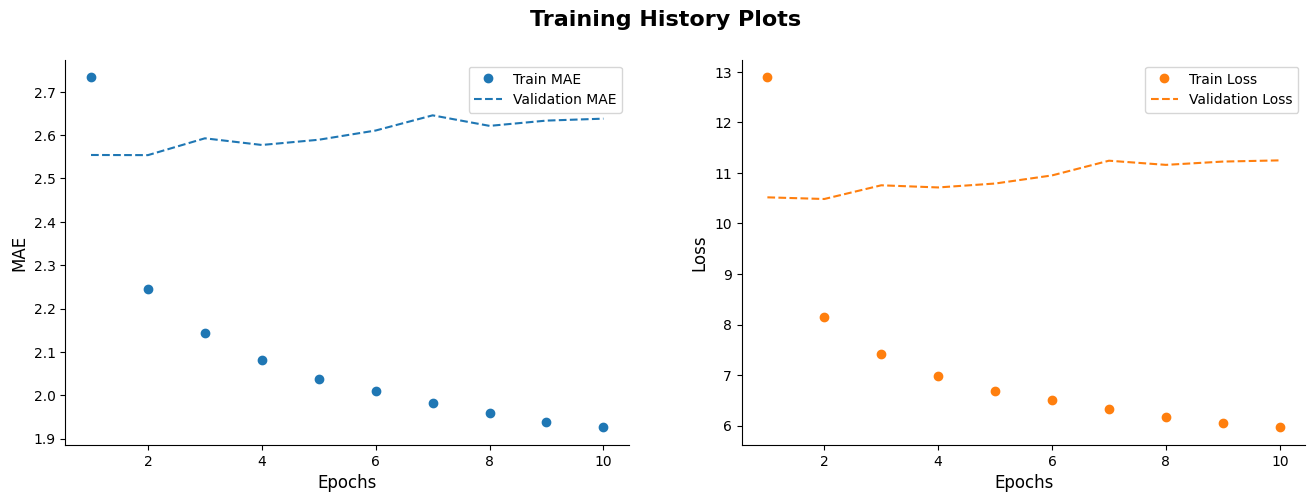

In [84]:
plot_history(history);

In [94]:
model = keras.models.load_model("jena_dense.keras")
dense_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {dense_mae:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 11.1353 - mae: 2.6318
Test MAE: 2.63


The test MAE is `2.63`, close, but it failed to beat the no-learning baseline of **2.62**. This goes to show the merit of having this baseline in the first place: it turns out to be not easy to outperform. Your common sense contains a lot of valuable information that a machine-learning model doesn’t have access to.

You may wonder, if a simple, well-performing model exists to go from the data to the targets (the common-sense baseline), why doesn’t the model you’re training find it and improve on it? Because this simple solution isn’t what your training setup is looking for. The space of models in which you’re searching for a solution—that is, your hypothesis space—is the space of all possible two-layer networks with the configuration
you defined. These networks are already fairly complicated. When you’re looking for a solution with a space of complicated models, the simple, well-performing baseline may be unlearnable, even if it’s technically part of the hypothesis space.

That is a pretty significant limitation of machine learning in general: **unless the learning algorithm is hardcoded to look for a specific kind of simple model, parameter learning can sometimes fail to find a simple solution to a simple problem.**

### 1D Convolutional Neural Network

Similarly, we can look at the performance of a 1D convolutional neural network. Our intuition for using this is as follows: since our input sequence feature daily cycles, perhaps a CNN would be able to capture those cycles in terms of the learned filters by the network.

We proceed to create a convolutional model by using the code below:

In [87]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [89]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 97, 8)          │         2,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 8)          │           776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,873 (15.13 KB)

 Trainable params: 3,873 (15.13 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [90]:
cnn_history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - loss: 25.2500 - mae: 3.8812 - val_loss: 15.6074 - val_mae: 3.1386
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - loss: 15.0153 - mae: 3.0734 - val_loss: 15.6839 - val_mae: 3.1474
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - loss: 13.6355 - mae: 2.9316 - val_loss: 15.5431 - val_mae: 3.1275
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 12.5028 - mae: 2.8013 - val_loss: 14.9349 - val_mae: 3.0736
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 11.5086 - mae: 2.6785 - val_loss: 15.5884 - val_mae: 3.1319
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 10.9047 - mae: 2.6031 - val_loss: 15.8032 - val_mae: 3.1573
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 10.4147 - mae: 2.5414 - val_loss: 15.2854 - val_mae: 3.0975
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 10.1017 - mae: 2.4993 - val_loss: 15.7273 - val_mae: 3.1458
Epoch 9/10
819/819 ━━━━━

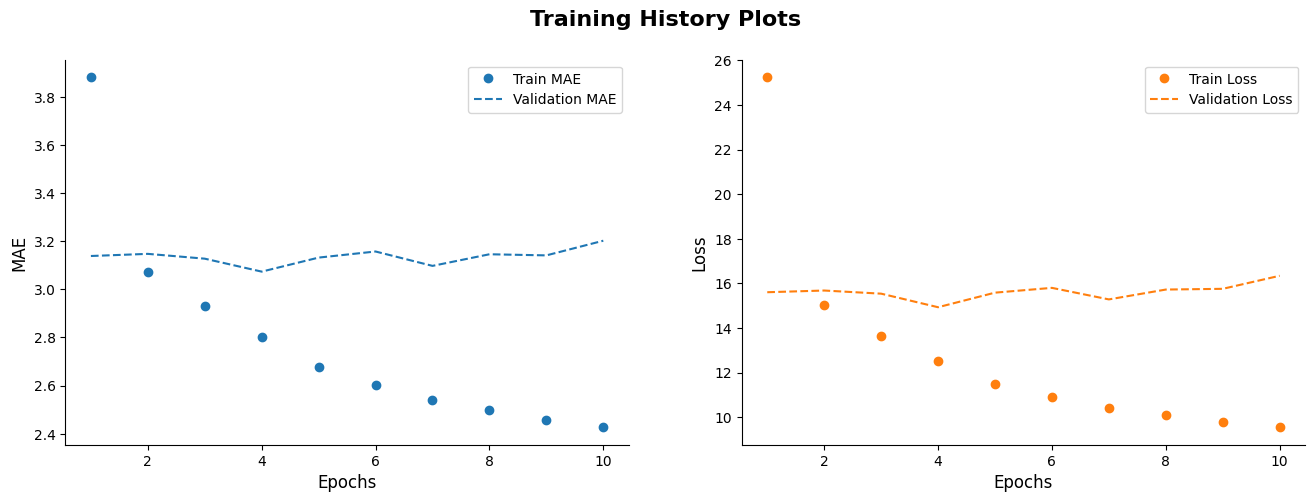

In [92]:
plot_history(cnn_history);

In [95]:
model = keras.models.load_model("jena_conv.keras")
cnn_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {cnn_mae:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 15.5996 - mae: 3.1244
Test MAE: 3.12


### LSTM

Now let's try to use an LSTM model to perform the same task.

In [97]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

/Users/llorenzo/miniforge3/envs/msds2026-ml3-macos/lib/python3.11/site-packages/keras/src/backend/torch/linalg.py:57: UserWarning: The operator 'aten::linalg_qr.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  return torch.linalg.qr(x, mode=mode)


In [98]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [100]:
lstm_history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 135s 163ms/step - loss: 49.5251 - mae: 5.2232 - val_loss: 19.2231 - val_mae: 3.2649
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 162ms/step - loss: 15.3634 - mae: 2.9617 - val_loss: 11.8710 - val_mae: 2.5888
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 134s 164ms/step - loss: 11.4301 - mae: 2.6138 - val_loss: 10.1535 - val_mae: 2.4596
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 164s 200ms/step - loss: 10.2013 - mae: 2.4806 - val_loss: 9.9399 - val_mae: 2.4426
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 171s 209ms/step - loss: 9.7378 - mae: 2.4250 - val_loss: 9.4683 - val_mae: 2.3905
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 162ms/step - loss: 9.3043 - mae: 2.3726 - val_loss: 9.5742 - val_mae: 2.4094
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 137s 167ms/step - loss: 8.8907 - mae: 2.3167 - val_loss: 9.6552 - val_mae: 2.4188
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 133s 162ms/step - loss: 8.6269 - mae: 2.2829 - val_loss: 9.6952 - val_mae: 2.4208
Epoch 9/10
819/81

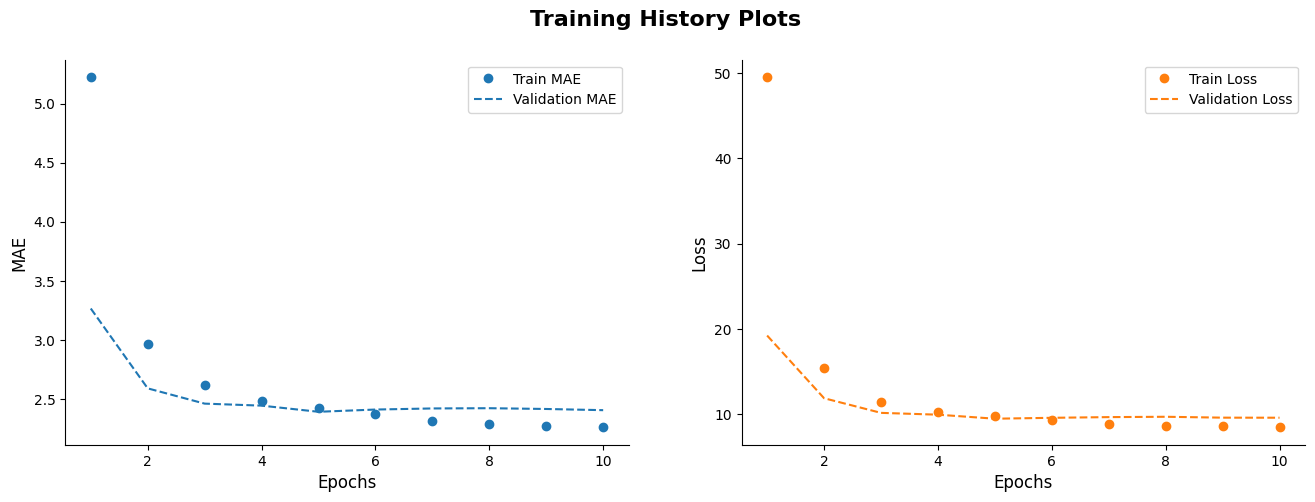

In [103]:
plot_history(lstm_history);

In [104]:
model = keras.models.load_model("jena_lstm.keras")
lstm_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {lstm_mae:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 10.9485 - mae: 2.5980
Test MAE: 2.60


## 5 RNN Regularization

It’s evident from the training and validation curves that the model is overfitting: the training and validation losses start to diverge considerably after a few epochs.

### Recurrent Dropout

You’re already familiar with a classic technique for fighting this phenomenon: dropout, which randomly zeros out input units of a layer in order to break incidental correlations in the training data that the layer is exposed to. But how to correctly apply dropout in recurrent networks isn’t a trivial question. It has long been known that applying dropout before a recurrent layer hinders learning rather than helping with regularization. In 2015, Yarin Gal, as part of his PhD thesis on Bayesian deep learning, determined the proper way to use dropout with a recurrent network: the same dropout mask (the same pattern of dropped units) should be applied at every timestep, instead of a dropout mask that varies randomly from timestep to timestep.

What’s more, in order to regularize the representations formed by the recurrent gates of layers such as GRU and LSTM, a temporally constant dropout mask should be applied to the inner recurrent activations of the layer (a recurrent dropout mask). Using the same dropout mask at every timestep allows the network to properly propagate its learning error through time; a temporally random dropout mask would disrupt this error signal and be harmful to the learning process.

Let’s add
dropout and recurrent dropout to the LSTM layer and see how doing so impacts overfitting. Because networks being regularized with dropout always take longer to fully converge, you’ll train the network for relatively more epochs for this network.

In [ ]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [101]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,005 (23.46 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,004 (15.64 KB)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
dropout_history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

In [ ]:
plot_history(dropout_history);

In [ ]:
model = keras.models.load_model("jena_lstm_dropout.keras")
dropout_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {dropout_mae:.2f}")

### Stacking Recurrent Layers

Because you’re no longer overfitting but seem to have hit a performance bottleneck, you should consider increasing the capacity of the network.

Recall the description of the universal machine-learning workflow: it’s generally a good idea to increase the capacity of your network until overfitting becomes the primary obstacle (assuming you’re already taking basic steps to mitigate overfitting, such as using dropout). As long as you aren’t overfitting too badly, you’re likely under capacity.    

Increasing network capacity is typically done by increasing the number of units in the layers or adding more layers. Recurrent layer stacking is a classic way to build more-powerful recurrent networks: for instance, what currently powers the Google to translate algorithm is a stack of seven large LSTM layers—that’s huge.   

To stack recurrent layers on top of each other in Keras, all intermediate layers should return their full sequence of outputs (a 3D tensor) rather than their output at the last timestep. This is done by specifying `return_sequences=True`.

In [ ]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [ ]:
model.summary()

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
stacked_history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

In [ ]:
plot_history(stacked_history);

In [ ]:
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
stacked_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {stacked_mae:.2f}")

### Bidirectional RNNs

A bidirectional RNN is a variant of RNN that can offer great performance than regular RNNs on certain task.

In [ ]:
inputs = keras.Input(shape=(sequence_length, predictors.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [102]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,005 (23.46 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,004 (15.64 KB)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_bidirectional.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
bidirectional_history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

In [ ]:
model = keras.models.load_model("jena_bidirectional.keras")
bidirectional_mae = model.evaluate(test_dataset)[1]
print(f"Test MAE: {bidirecational_mae:.2f}")

### Further Tuning

There are many other things you could try, in order to improve performance on the temperature-forecasting problem:

- Adjust the number of units in each recurrent layer in the stacked setup, as well as the amount of dropout.
- Adjust the learning rate used by the optimizer.
- Try using a bigger densely connected regressor on top of the recurrent layers: that is, a bigger Dense layer or even a stack of Dense layers.
- Improve the input to the model: try using longer or shorter sequences or a different sampling rate, or start doing feature engineering.

Deep learning right now is still more like an art than a science. We can provide guidelines that suggest what is likely to work or not work on a given problem, but, ultimately, every problem is unique; you’ll have to evaluate different strategies empirically. There is currently no theory that will tell you in advance precisely what you should do to optimally solve a problem. You must iterate.

<img src="images/banner-down.png" style="width: 100%;">